# 🎯 AI Career Discovery Engine — v3
### Hybrid ML × Ikigai × Behavioral Pattern Analysis × Market Intelligence

---

**Architecture**
```
career_recommendation/
├── assessment.py    — Ikigai + hidden behavioral question engine
├── personality.py   — Adaptive embeddings, contradiction detection, hidden potential
├── market.py        — Market intelligence (salary, GCC demand, automation risk)
├── ml_pipeline.py   — 5-stage hybrid ML scoring pipeline
└── Career_System_v3.ipynb  ← you are here
```

**5-Stage Scoring Pipeline**

| Stage | Method | Weight |
|-------|--------|--------|
| 1 | Cosine Similarity | 35% |
| 2 | K-Means Clustering | 10% |
| 3 | Weighted Dot Product | 25% |
| 4 | Ikigai Alignment | 15% |
| 5 | Market Intelligence | 15% |

---


In [2]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Circle, FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# Make sure modules are importable from the same directory
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from assessment  import run_assessment, FEATURE_NAMES, BEHAVIORAL_DIMS, IKIGAI_QUADRANTS
from personality import run_personality_analysis, ARCHETYPES, ARCHETYPE_DESCRIPTIONS
from market      import get_market_profile, format_salary, MARKET_DATA
from ml_pipeline import run_pipeline, CAREERS, CAREER_MATRIX

print('✅ All modules loaded.')
print(f'   assessment.py  — {len(FEATURE_NAMES)} features, 8 questions')
print(f'   personality.py — {len(ARCHETYPES)} archetypes, 8 hidden potential traits')
print(f'   market.py      — {len(MARKET_DATA)} careers with market intelligence')
print(f'   ml_pipeline.py — 5-stage scoring pipeline')


✅ All modules loaded.
   assessment.py  — 12 features, 8 questions
   personality.py — 8 archetypes, 8 hidden potential traits
   market.py      — 20 careers with market intelligence
   ml_pipeline.py — 5-stage scoring pipeline


---
## Step 1 — Assessment

8 questions across Ikigai quadrants + hidden behavioral dimensions.  
Select **all options that apply** per question using comma-separated numbers.


In [3]:
user_vector, ikigai_scores, behavioral_vec, user_answers = run_assessment()



  🎯  AI CAREER DISCOVERY ENGINE
  Powered by Ikigai × Behavioral Pattern Analysis

  Select ALL options that feel true for you.
  Enter numbers separated by commas — e.g.  1, 3, 5
  There are no right or wrong answers.


──────────────────────────────────────────────────────────────
  Question 1/8  |  ❤️  What You Love
──────────────────────────────────────────────────────────────

  Which of these genuinely light you up? (Select all that apply)

    [1] Building & engineering things
    [2] Creating art, music, or visual work
    [3] Helping & deeply connecting with people
    [4] Researching & discovering new things
    [5] Leading teams & making big decisions
    [6] Solving complex logical puzzles



  Your choices (e.g. 1, 3 or just 2):  1,3


  ✓  2 selected.

──────────────────────────────────────────────────────────────
  Question 2/8  |  💪 What You're Good At
──────────────────────────────────────────────────────────────

  What do people actually come to you for? (Select all that apply)

    [1] Math, logic, and analytical thinking
    [2] Writing, storytelling, communication
    [3] Designing and visualizing ideas
    [4] Organizing, planning, and executing
    [5] Building and debugging technical systems
    [6] Persuading, negotiating, influencing



  Your choices (e.g. 1, 3 or just 2):  1,2,3


  ✓  3 selected.

──────────────────────────────────────────────────────────────
  Question 3/8  |  🌍 What the World Needs
──────────────────────────────────────────────────────────────

  Which problems feel most urgent to you? (Select all that apply)

    [1] Healthcare & human wellbeing
    [2] Technology & digital transformation
    [3] Education & knowledge access
    [4] Business, economy & financial systems
    [5] Environment, infrastructure & cities
    [6] Culture, arts & human expression


...

  ✓  2 selected.

──────────────────────────────────────────────────────────────
  Question 7/8  |  🔥 Under Pressure
──────────────────────────────────────────────────────────────

  When a deadline hits and things get hard, you typically... (Select all that apply)

    [1] Break it down into smaller steps and grind
    [2] Get energized — pressure activates me
    [3] Reach out for help or collaboration
    [4] Step back and rethink the whole approach
    [5] Push through on instinct and momentum



  Your choices (e.g. 1, 3 or just 2):  4


  ✓  1 selected.

──────────────────────────────────────────────────────────────
  Question 8/8  |  🔭 When Something Interests You
──────────────────────────────────────────────────────────────

  How far down the rabbit hole do you usually go? (Select all that apply)

    [1] I read everything — papers, books, forums
    [2] I build or make something to understand it
    [3] I find people to talk to about it
    [4] I skim the surface — enough to get the picture
    [5] I get obsessed and go extremely deep



  Your choices (e.g. 1, 3 or just 2):  2


  ✓  1 selected.

  ✅  Assessment complete. Analysing your profile...


---
## Step 2 — Personality Analysis


In [4]:
personality = run_personality_analysis(user_vector, behavioral_vec)
emb = personality['embedding']

print('\n' + '═'*62)
print('  🧠  PERSONALITY PROFILE')
print('═'*62)
print(f"\n  Archetype:    {emb['archetype']}  ({emb['archetype_score']:.0f}% match)")
print(f"  Secondary:    {emb['secondary_archetype']}")
print(f"  Description:  {emb['archetype_description']}")

print('\n  Behavioral Dimensions:')
from assessment import BEHAVIORAL_DIMS
for dim, val in zip(BEHAVIORAL_DIMS, behavioral_vec):
    filled = int(val * 20)
    bar    = '█'*filled + '░'*(20-filled)
    print(f'    {dim:<24} [{bar}] {val:.2f}')

# ── Contradictions
print('\n' + '─'*62)
contradictions = personality['contradictions']
if contradictions:
    print(f'  ⚡  DETECTED {len(contradictions)} CONTRADICTION(S) IN YOUR PROFILE')
    print('─'*62)
    for c in contradictions:
        print(f"\n  [{c['name']}]")
        print(f"  • You stated:   {c['stated']}")
        print(f"  • We detected:  {c['detected']}")
        print(f"  • Insight:      {c['insight']}")
else:
    print('  ✅  No significant contradictions detected — your profile is consistent.')

# ── Hidden Potential
print('\n' + '─'*62)
hidden = personality['hidden_potential']
if hidden:
    print(f'  🌟  HIDDEN POTENTIAL DETECTED ({len(hidden)} trait(s))')
    print('─'*62)
    for h in hidden:
        print(f"\n  [{h['trait']}]")
        print(f"  {h['description']}")
        print(f"  → Unlocks: {', '.join(h['careers'][:3])}")
else:
    print('  Profile is well-matched to your stated interests.')
print('\n' + '═'*62)



══════════════════════════════════════════════════════════════
  🧠  PERSONALITY PROFILE
══════════════════════════════════════════════════════════════

  Archetype:    The Scientist  (98% match)
  Secondary:    The Architect
  Description:  You need to understand deeply. Surface-level answers frustrate you.

  Behavioral Dimensions:
    structure_preference     [████████████████░░░░] 0.84
    risk_tolerance           [█████████████░░░░░░░] 0.69
    motivation_type          [██████████░░░░░░░░░░] 0.52
    social_orientation       [███████████░░░░░░░░░] 0.56
    ambiguity_tolerance      [████████████░░░░░░░░] 0.63
    analytical_bias          [██████████████████░░] 0.94
    execution_bias           [████████████████████] 1.00
    curiosity_breadth        [█████████████████░░░] 0.88

──────────────────────────────────────────────────────────────
  ✅  No significant contradictions detected — your profile is consistent.

──────────────────────────────────────────────────────────────
  🌟  H

---
## Step 3 — ML Pipeline (5 Stages)


In [5]:
ranked, user_cluster, cluster_map = run_pipeline(user_vector, ikigai_scores, personality)
top5 = ranked[:5]

print('5-Stage Pipeline Results — All 20 Careers')
print(f"{'Rk':<4} {'Career':<26} {'%Fit':<7} {'Cos':<7} {'Dot':<7} {'Iki':<7} {'Mkt':<7} {'Cluster'}")
print('─'*78)
for rk, c in enumerate(ranked, 1):
    cl = '✓' if c['in_cluster'] else '✗'
    mk = ' ⭐' if rk <= 5 else ''
    print(f"  {rk:<3} {c['career']:<26} {c['percent']:>5.1f}%  "
          f"{c['cosine']:.3f}  {c['dot']:.3f}  {c['ikigai_sim']:.3f}  "
          f"{c['market']:.3f}  {cl}{mk}")

print(f"\n  You are in Cluster {user_cluster}: {cluster_map[user_cluster]}")


5-Stage Pipeline Results — All 20 Careers
Rk   Career                     %Fit    Cos     Dot     Iki     Mkt     Cluster
──────────────────────────────────────────────────────────────────────────────
  1   Cybersecurity Analyst       98.0%  0.904  0.037  0.982  0.938  ✗ ⭐
  2   Civil Engineer              96.7%  0.948  0.038  0.981  0.740  ✓ ⭐
  3   Data Scientist              95.8%  0.912  0.039  0.992  0.879  ✗ ⭐
  4   Software Engineer           92.6%  0.918  0.038  0.992  0.832  ✗ ⭐
  5   Biomedical Engineer         90.3%  0.935  0.038  0.989  0.691  ✓ ⭐
  6   Doctor                      89.5%  0.908  0.038  0.992  0.739  ✓
  7   Researcher                  89.1%  0.937  0.036  0.990  0.671  ✓
  8   Architect                   87.3%  0.938  0.037  0.998  0.719  ✗
  9   Mechanical Engineer         86.4%  0.935  0.037  0.993  0.642  ✓
  10  Product Manager             82.4%  0.895  0.037  0.995  0.767  ✗
  11  Entrepreneur                78.1%  0.871  0.038  0.998  0.770  ✗
  12  Fi

---
## Step 4 — 🎯 Your Results


In [6]:
CAREER_INSIGHTS = {
    'Software Engineer':     'Analytical + technical profile. Massive, sustained global demand.',
    'Data Scientist':        'Science + analytical dimensions drive this. Fastest-growing tech role in MENA.',
    'UX Designer':           'Creativity + social awareness. GCC digital transformation needs this urgently.',
    'Product Manager':       'Leadership + business sense. Most automation-resilient tech role.',
    'Cybersecurity Analyst': 'Technical depth + detail. Critical national shortage across GCC.',
    'Doctor':                'Science + social strength. GCC healthcare expansion under Vision 2030.',
    'Biomedical Engineer':   'Technical + science + AI convergence. Emerging role in MENA.',
    'Architect':             'Creativity + technical + detail. NEOM and giga-projects are driving demand.',
    'Civil Engineer':        'Analytical + technical. Saudi infrastructure pipeline is $1T+.',
    'Mechanical Engineer':   'Technical + science. Stable demand with robotics integration.',
    'Financial Analyst':     'Analytical + business. High AI augmentation; human oversight still critical.',
    'Entrepreneur':          'Leadership + business + creativity. MENA VC at record levels.',
    'Lawyer':                'Communication + analytical. Resilient to automation at the senior level.',
    'Psychologist':          'Social + communication. GCC mental health awareness is growing fast.',
    'Teacher':               'Communication + social. EdTech is augmenting, not replacing.',
    'Researcher':            'Analytical + science + detail. AI tools multiplying researcher output.',
    'Graphic Designer':      'High creativity. High AI disruption risk — move toward creative direction.',
    'Marketing Manager':     'Communication + business + creativity. AI-powered marketing needs strategists.',
    'Journalist':            'Communication + arts. Investigative and specialist journalism is resilient.',
    'Content Creator':       'Creativity + communication. Creator economy: $250B by 2027.',
}

medals = ['🥇','🥈','🥉','4️⃣ ','5️⃣ ']

print('╔' + '═'*62 + '╗')
print('║' + '  🎯  YOUR TOP 5 CAREER MATCHES'.center(62) + '║')
print('╚' + '═'*62 + '╝\n')

for i, c in enumerate(top5):
    pct = c['percent']
    mp  = get_market_profile(c['career'])
    bar = '█'*int(pct/5) + '░'*(20-int(pct/5))

    print(f"  {medals[i]}  {c['career']}")
    print(f"       Fit Score:       [{bar}] {pct:.1f}%")
    print(f"       Salary (USD):    {format_salary(c['career'])}")
    print(f"       GCC Opportunity: {mp.get('gcc_opportunity',0)}/100  |  "
          f"Automation Risk: {mp.get('automation_risk_pct',0)}%  |  "
          f"5yr Growth: +{mp.get('growth_5yr_pct',0)}%")
    print(f"       Ikigai Align:    {c['ikigai_sim']:.0%}  |  "
          f"Market Score: {c['market']:.0%}  |  "
          f"Cluster: {'✓ in your group' if c['in_cluster'] else '✗'}")
    print(f"       Why: {CAREER_INSIGHTS.get(c['career'],'Strong match.')}")
    if mp.get('emerging_role'):
        print(f'       🚀 EMERGING ROLE — net-new or fast-growing in MENA')
    print()

# Ikigai summary
print('─'*64)
print('  Your Ikigai Profile:')
iki_labels = {'love':'❤️  Love','good_at':'💪 Good At','world_needs':'🌍 World Needs','paid_for':'💰 Paid For'}
for q, label in iki_labels.items():
    score = ikigai_scores[q]
    bar   = '█'*int(score/5) + '░'*(20-int(score/5))
    print(f'    {label:<20} [{bar}] {score:.0f}/100')

# Hidden potential callout
hidden = personality['hidden_potential']
if hidden:
    print('\n  🌟 Your Hidden Potential:')
    for h in hidden:
        print(f"    • {h['trait']}: {h['description'][:70]}...")

print('\n' + '─'*64)
print(f"  Personality Archetype: {personality['embedding']['archetype']}")
print(f"  {personality['embedding']['archetype_description']}")
print('─'*64)


╔══════════════════════════════════════════════════════════════╗
║                  🎯  YOUR TOP 5 CAREER MATCHES                ║
╚══════════════════════════════════════════════════════════════╝

  🥇  Cybersecurity Analyst
       Fit Score:       [███████████████████░] 98.0%
       Salary (USD):    $70K – $160K
       GCC Opportunity: 98/100  |  Automation Risk: 15%  |  5yr Growth: +40%
       Ikigai Align:    98%  |  Market Score: 94%  |  Cluster: ✗
       Why: Technical depth + detail. Critical national shortage across GCC.
       🚀 EMERGING ROLE — net-new or fast-growing in MENA

  🥈  Civil Engineer
       Fit Score:       [███████████████████░] 96.7%
       Salary (USD):    $55K – $120K
       GCC Opportunity: 92/100  |  Automation Risk: 30%  |  5yr Growth: +20%
       Ikigai Align:    98%  |  Market Score: 74%  |  Cluster: ✓ in your group
       Why: Analytical + technical. Saudi infrastructure pipeline is $1T+.

  🥉  Data Scientist
       Fit Score:       [███████████████████░] 9

---
## Step 5 — Visualizations


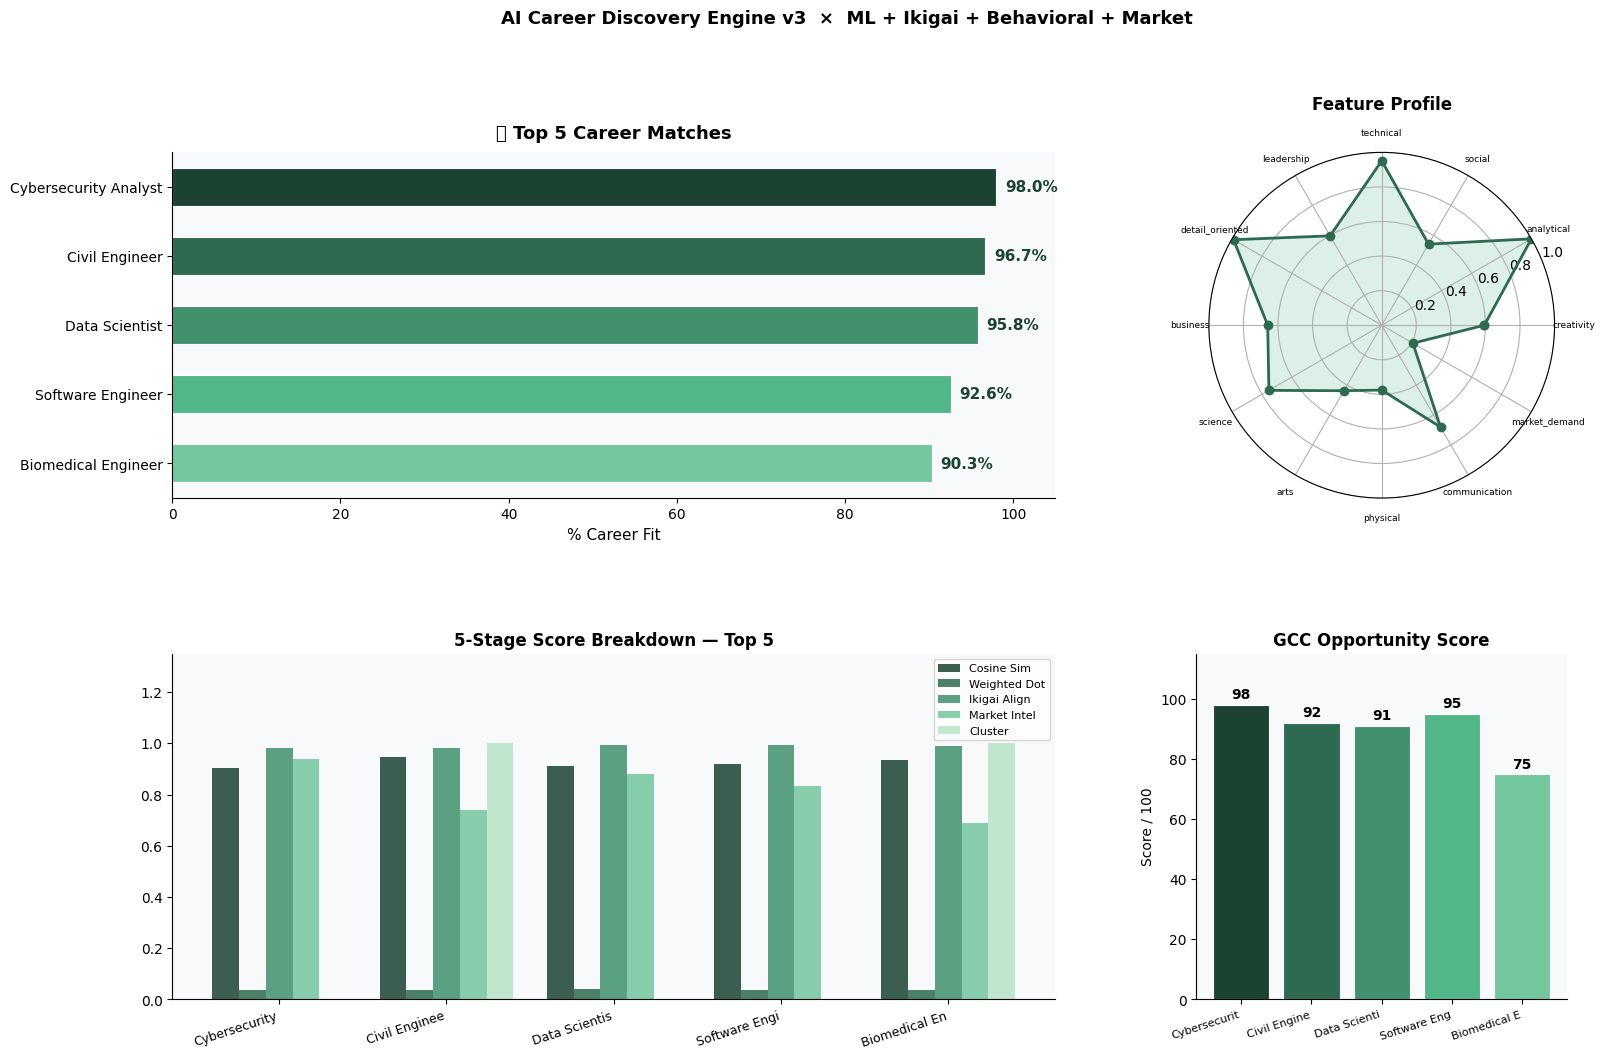

✅ Dashboard saved.


In [7]:
# ── Figure 1: 4-Panel Dashboard
fig = plt.figure(figsize=(18, 11))
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

GREEN = ['#1B4332','#2D6A4F','#40916C','#52B788','#74C69D']

# Panel 1: Top 5 bar chart
ax1 = fig.add_subplot(gs[0,:2])
names = [c['career'] for c in top5]
pcts  = [c['percent'] for c in top5]
bars  = ax1.barh(names[::-1], pcts[::-1], color=GREEN[::-1],
                 edgecolor='white', linewidth=0.8, height=0.55)
ax1.set_xlim(0,105)
ax1.set_xlabel('% Career Fit', fontsize=11)
ax1.set_title('🎯 Top 5 Career Matches', fontsize=13, fontweight='bold', pad=10)
for bar, p in zip(bars, pcts[::-1]):
    ax1.text(p+1, bar.get_y()+bar.get_height()/2,
             f'{p:.1f}%', va='center', fontsize=11, fontweight='bold', color='#1B4332')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_facecolor('#F8F9FA')

# Panel 2: Profile Radar
ax2 = fig.add_subplot(gs[0,2], projection='polar')
from assessment import FEATURE_NAMES
angles = np.linspace(0,2*np.pi,len(FEATURE_NAMES),endpoint=False).tolist()
vals   = user_vector.tolist(); angles += angles[:1]; vals += vals[:1]
ax2.plot(angles,vals,'o-',lw=2,color='#2D6A4F')
ax2.fill(angles,vals,alpha=0.2,color='#52B788')
ax2.set_xticks(angles[:-1]); ax2.set_xticklabels(FEATURE_NAMES,size=6.5)
ax2.set_ylim(0,1)
ax2.set_title('Feature Profile', size=12, fontweight='bold', pad=14)

# Panel 3: 5-Component Score Breakdown
ax3 = fig.add_subplot(gs[1,:2])
x = np.arange(len(top5)); w = 0.16
ax3.bar(x-2*w,[c['cosine']     for c in top5],w,label='Cosine Sim',   color='#1B4332',alpha=0.85)
ax3.bar(x-1*w,[c['dot']        for c in top5],w,label='Weighted Dot', color='#2D6A4F',alpha=0.85)
ax3.bar(x+0*w,[c['ikigai_sim'] for c in top5],w,label='Ikigai Align', color='#40916C',alpha=0.85)
ax3.bar(x+1*w,[c['market']     for c in top5],w,label='Market Intel', color='#74C69D',alpha=0.85)
ax3.bar(x+2*w,[1 if c['in_cluster'] else 0 for c in top5],w,label='Cluster',color='#B7E4C7',alpha=0.85)
ax3.set_xticks(x)
ax3.set_xticklabels([c['career'][:13] for c in top5],rotation=18,ha='right',fontsize=9)
ax3.set_ylim(0,1.35); ax3.legend(fontsize=8,loc='upper right')
ax3.set_title('5-Stage Score Breakdown — Top 5', fontsize=12, fontweight='bold')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)
ax3.set_facecolor('#F8F9FA')

# Panel 4: Market Intelligence
ax4 = fig.add_subplot(gs[1,2])
mkt_vals = [get_market_profile(c['career'])['gcc_opportunity'] for c in top5]
mkt_cols = ['#1B4332','#2D6A4F','#40916C','#52B788','#74C69D']
b4 = ax4.bar([c['career'][:12] for c in top5], mkt_vals, color=mkt_cols,
             edgecolor='white', linewidth=0.8)
ax4.set_ylim(0,115); ax4.set_title('GCC Opportunity Score', fontsize=12, fontweight='bold')
ax4.set_ylabel('Score / 100')
for bar, v in zip(b4, mkt_vals):
    ax4.text(bar.get_x()+bar.get_width()/2, v+2, f'{v}',
             ha='center', fontsize=10, fontweight='bold')
ax4.set_xticklabels([c['career'][:12] for c in top5],rotation=18,ha='right',fontsize=8)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)
ax4.set_facecolor('#F8F9FA')

fig.suptitle('AI Career Discovery Engine v3  ×  ML + Ikigai + Behavioral + Market',
             fontsize=13, fontweight='bold', y=1.01)
plt.savefig('dashboard_v3.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print('✅ Dashboard saved.')


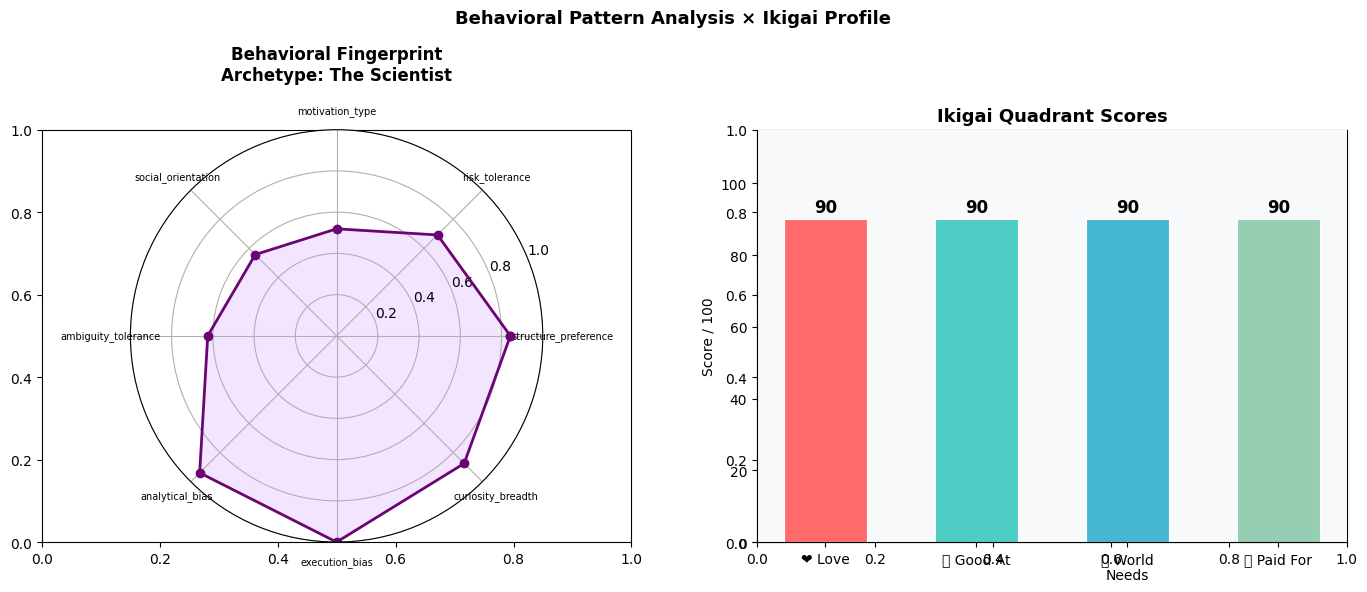

In [8]:
# ── Figure 2: Behavioral Fingerprint
fig, axes = plt.subplots(1,2,figsize=(14,6))

ax = fig.add_subplot(121, projection='polar')
b_angles = np.linspace(0,2*np.pi,len(BEHAVIORAL_DIMS),endpoint=False).tolist()
b_vals   = behavioral_vec.tolist()
b_angles += b_angles[:1]; b_vals += b_vals[:1]
ax.plot(b_angles,b_vals,'o-',lw=2,color='#6A0572')
ax.fill(b_angles,b_vals,alpha=0.2,color='#C77DFF')
ax.set_xticks(b_angles[:-1])
ax.set_xticklabels(BEHAVIORAL_DIMS,size=7)
ax.set_ylim(0,1)
ax.set_title(f"Behavioral Fingerprint\nArchetype: {personality['embedding']['archetype']}",
             size=12, fontweight='bold', pad=18)

ax2 = fig.add_subplot(122)
iki_vals  = [ikigai_scores[q] for q in ['love','good_at','world_needs','paid_for']]
iki_cols  = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4']
iki_short = ['❤️ Love','💪 Good At','🌍 World\nNeeds','💰 Paid For']
b = ax2.bar(iki_short,iki_vals,color=iki_cols,edgecolor='white',linewidth=0.8,width=0.55)
ax2.set_ylim(0,115)
ax2.set_title('Ikigai Quadrant Scores', fontsize=13, fontweight='bold')
ax2.set_ylabel('Score / 100')
for bar, v in zip(b,iki_vals):
    ax2.text(bar.get_x()+bar.get_width()/2,v+2,f'{v:.0f}',
             ha='center',fontsize=12,fontweight='bold')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.set_facecolor('#F8F9FA')

fig.suptitle('Behavioral Pattern Analysis × Ikigai Profile', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('behavioral_v3.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()


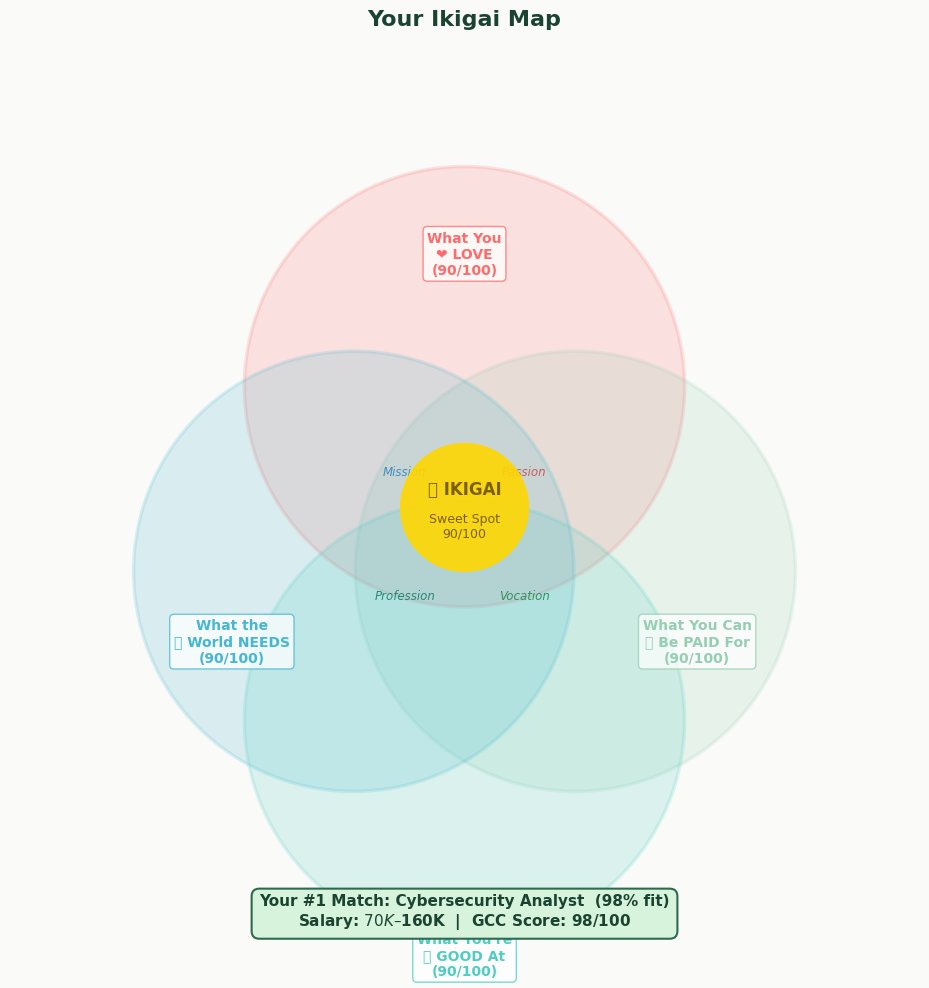

✅ Ikigai diagram saved.


In [9]:
# ── Figure 3: Ikigai Venn Diagram
fig, ax = plt.subplots(figsize=(10,10))
ax.set_xlim(-3.2,3.2); ax.set_ylim(-3.2,3.2)
ax.set_aspect('equal'); ax.axis('off')
fig.patch.set_facecolor('#FAFAF8')

R = 1.55
positions = [
    (0,    0.85, '#FF6B6B', f"What You\n❤️ LOVE\n({ikigai_scores['love']:.0f}/100)"),
    (0.78,-0.45, '#96CEB4', f"What You Can\n💰 Be PAID For\n({ikigai_scores['paid_for']:.0f}/100)"),
    (-0.78,-0.45,'#45B7D1', f"What the\n🌍 World NEEDS\n({ikigai_scores['world_needs']:.0f}/100)"),
    (0,  -1.5,  '#4ECDC4', f"What You're\n💪 GOOD At\n({ikigai_scores['good_at']:.0f}/100)"),
]
for cx,cy,color,label in positions:
    from matplotlib.patches import Circle
    ax.add_patch(Circle((cx,cy),R,color=color,alpha=0.18,linewidth=2.5,edgecolor=color))
    lx = cx*2.1; ly = cy*2.1
    if abs(lx)<0.3: lx=0
    if abs(ly)<0.3: ly=cy*2.4
    ax.text(lx,ly,label,ha='center',va='center',fontsize=10,fontweight='bold',color=color,
            bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.75,edgecolor=color))

iki_mean = np.mean(list(ikigai_scores.values()))
ax.add_patch(Circle((0,0),0.45,color='#FFD700',alpha=0.9,zorder=5))
ax.text(0,0.13,'✨ IKIGAI',ha='center',va='center',fontsize=12,fontweight='bold',color='#7B6000',zorder=6)
ax.text(0,-0.13,f'Sweet Spot\n{iki_mean:.0f}/100',ha='center',va='center',fontsize=9,color='#7B6000',zorder=6)

for ix,iy,label,color in [(0.42,0.25,'Passion','#CC4444'),(-0.42,0.25,'Mission','#2980B9'),
                            (0.42,-0.62,'Vocation','#1E8449'),(-0.42,-0.62,'Profession','#117A65')]:
    ax.text(ix,iy,label,ha='center',va='center',fontsize=8.5,style='italic',color=color,alpha=0.85)

top1 = top5[0]
ax.text(0,-2.85,
        f"Your #1 Match: {top1['career']}  ({top1['percent']:.0f}% fit)\n"
        f"Salary: {format_salary(top1['career'])}  |  GCC Score: {get_market_profile(top1['career'])['gcc_opportunity']}/100",
        ha='center',va='center',fontsize=11,fontweight='bold',color='#1B4332',
        bbox=dict(boxstyle='round,pad=0.5',facecolor='#D8F3DC',edgecolor='#2D6A4F',linewidth=1.5))

ax.set_title('Your Ikigai Map',fontsize=16,fontweight='bold',pad=20,color='#1B4332')
plt.tight_layout()
plt.savefig('ikigai_v3.png',dpi=150,bbox_inches='tight',facecolor='#FAFAF8')
plt.show()
print('✅ Ikigai diagram saved.')


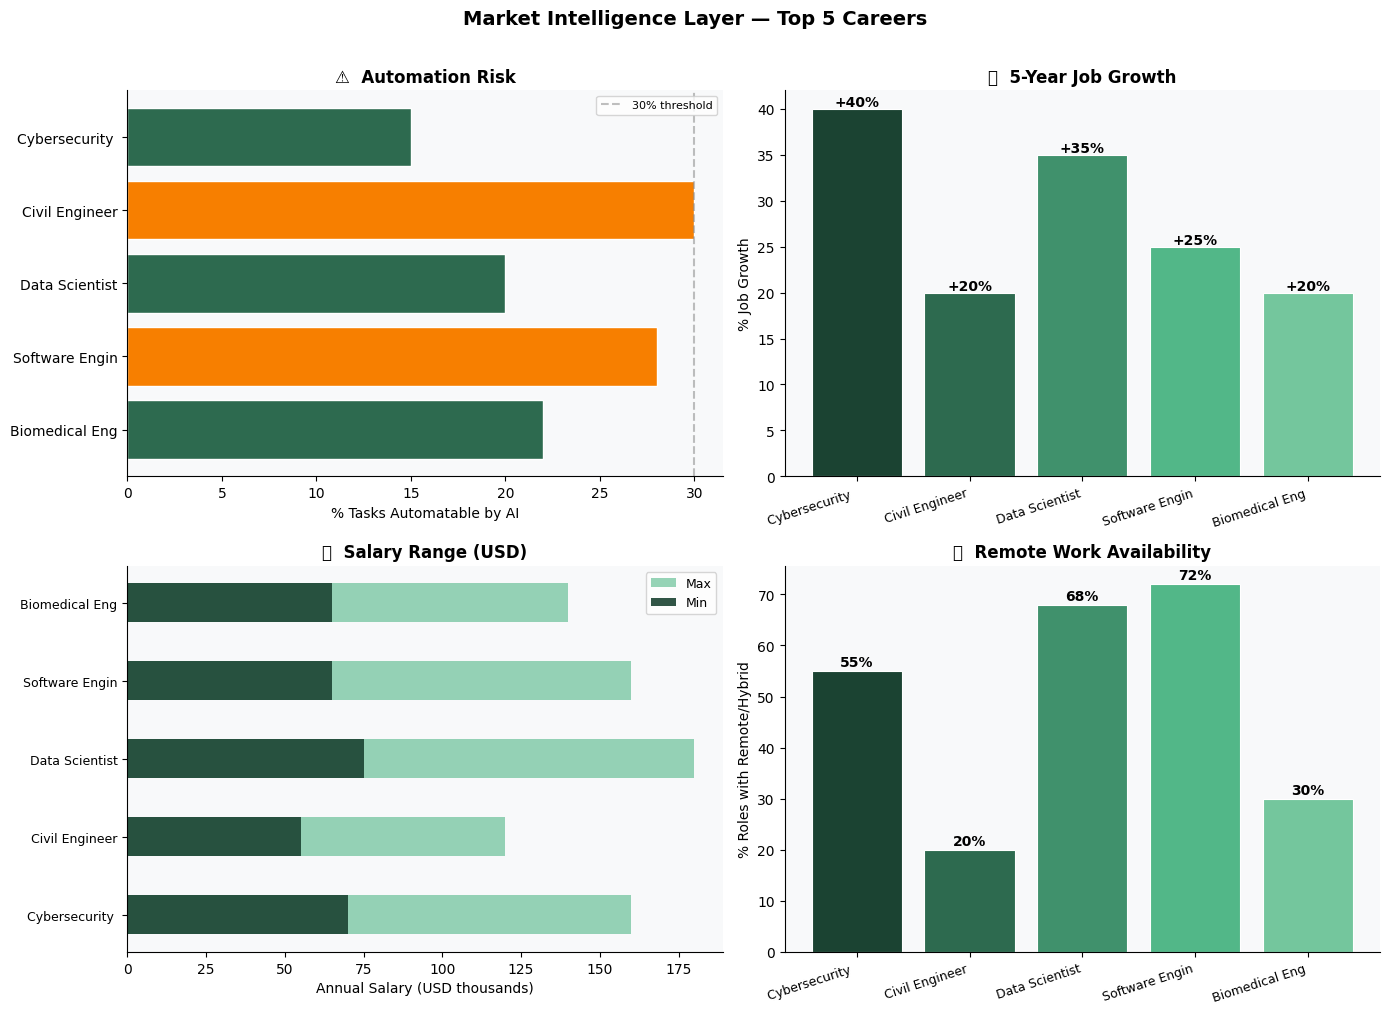


✅ All visualizations saved:
   dashboard_v3.png | behavioral_v3.png | ikigai_v3.png | market_v3.png


In [10]:
# ── Figure 4: Market Intelligence Dashboard
fig, axes = plt.subplots(2,2,figsize=(14,10))
fig.suptitle('Market Intelligence Layer — Top 5 Careers',fontsize=14,fontweight='bold',y=1.01)

c_names  = [c['career'] for c in top5]
c_short  = [n[:14] for n in c_names]
GREEN5   = ['#1B4332','#2D6A4F','#40916C','#52B788','#74C69D']

# Automation Risk
ax = axes[0,0]
risks = [get_market_profile(n)['automation_risk_pct'] for n in c_names]
risk_colors = ['#D62828' if r>40 else '#F77F00' if r>25 else '#2D6A4F' for r in risks]
ax.barh(c_short[::-1],risks[::-1],color=risk_colors[::-1],edgecolor='white')
ax.set_xlabel('% Tasks Automatable by AI')
ax.set_title('⚠️  Automation Risk', fontweight='bold')
ax.axvline(30,color='gray',linestyle='--',alpha=0.5,label='30% threshold')
ax.legend(fontsize=8); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_facecolor('#F8F9FA')

# 5-Year Growth
ax = axes[0,1]
growth = [get_market_profile(n)['growth_5yr_pct'] for n in c_names]
ax.bar(c_short,growth,color=GREEN5,edgecolor='white',linewidth=0.8)
ax.set_ylabel('% Job Growth'); ax.set_title('📈  5-Year Job Growth', fontweight='bold')
for i,(bar,g) in enumerate(zip(ax.patches,growth)):
    ax.text(bar.get_x()+bar.get_width()/2,g+0.3,f'+{g}%',ha='center',fontsize=10,fontweight='bold')
ax.set_xticklabels(c_short,rotation=18,ha='right',fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_facecolor('#F8F9FA')

# Salary Ranges
ax = axes[1,0]
sal_lo = [get_market_profile(n)['salary_usd_range'][0]//1000 for n in c_names]
sal_hi = [get_market_profile(n)['salary_usd_range'][1]//1000 for n in c_names]
y = np.arange(len(c_names))
ax.barh(y,sal_hi,color='#52B788',alpha=0.6,label='Max',height=0.5)
ax.barh(y,sal_lo,color='#1B4332',alpha=0.9,label='Min',height=0.5)
ax.set_yticks(y); ax.set_yticklabels(c_short,fontsize=9)
ax.set_xlabel('Annual Salary (USD thousands)')
ax.set_title('💰  Salary Range (USD)', fontweight='bold')
ax.legend(fontsize=9); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_facecolor('#F8F9FA')

# Remote Work %
ax = axes[1,1]
remote = [get_market_profile(n)['remote_work_pct'] for n in c_names]
ax.bar(c_short,remote,color=GREEN5,edgecolor='white',linewidth=0.8)
ax.set_ylabel('% Roles with Remote/Hybrid'); ax.set_title('🌐  Remote Work Availability', fontweight='bold')
for bar,r in zip(ax.patches,remote):
    ax.text(bar.get_x()+bar.get_width()/2,r+1,f'{r}%',ha='center',fontsize=10,fontweight='bold')
ax.set_xticklabels(c_short,rotation=18,ha='right',fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_facecolor('#F8F9FA')

plt.tight_layout()
plt.savefig('market_v3.png',dpi=150,bbox_inches='tight',facecolor='white')
plt.show()
print('\n✅ All visualizations saved:')
print('   dashboard_v3.png | behavioral_v3.png | ikigai_v3.png | market_v3.png')
